In [1]:
 %load_ext autoreload
%autoreload 2
import numpy as np
from utils_final_results import load_dataset
from hydra import compose
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from utils_table_generator import get_mean_std, flatten_config
from omegaconf import OmegaConf

/home/gbg141/TopoProteo/tutorials/utils_final_results.py:55: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs", job_name="job")


In [18]:
def construct_dataset(dataset):
    X_list = []
    y_list = []
    sex_list = []
    mutation_list = []
    age_list = []

    for data in dataset:
        graph_feat = data.x.view(-1).numpy()
        X_list.append(graph_feat)
        y_list.append(data.y.item())
        sex_list.append(data.sex.item())
        mutation_list.append(data.mutation.item())
        age_list.append(data.age.item())

    X = np.vstack(X_list)
    y = np.array(y_list)

    sex = np.array(sex_list).reshape(-1, 1)
    mutation = np.array(mutation_list).reshape(-1, 1)
    age = np.array(age_list).reshape(-1, 1)

    return X, y, sex, mutation, age


def stack_features(train_features, train_labels, train_sex, train_mutation, train_age, val_features, val_labels, val_sex, val_mutation, val_age):
    target_shape = train_features.shape[1] // 3
    if train_sex.shape[1] < target_shape:
        # Calculate how many times to repeat train_sex along the second axis
        repeat_times = target_shape // train_sex.shape[1]
        train_sex = np.tile(train_sex, (1, repeat_times))
        val_sex = np.tile(val_sex, (1, repeat_times))
        train_mutation = np.tile(train_mutation, (1, repeat_times))
        val_mutation = np.tile(val_mutation, (1, repeat_times))
        train_age = np.tile(train_age, (1, repeat_times))
        val_age = np.tile(val_age, (1, repeat_times))

    train_combined = np.hstack((train_features, train_sex, train_mutation, train_age))
    print(train_combined.shape)
    val_combined = np.hstack((val_features, val_sex, val_mutation, val_age))
    print(val_combined.shape)
    return train_combined, val_combined, train_labels, val_labels

def concat_features(train_features, train_labels, train_sex, train_mutation, train_age, val_features, val_labels, val_sex, val_mutation, val_age):
    train_combined = np.hstack((train_features, train_sex, train_mutation, train_age))
    val_combined = np.hstack((val_features, val_sex, val_mutation, val_age))
    return train_combined, val_combined, train_labels, val_labels

def convert_results(norm_mean, adj_metric, adj_thresh, k_fold, num_folds, fold) :
    cfg = compose(
        config_name="run.yaml",
        overrides=[
            "model=graph/gcn",
            "dataset=graph/FTD",
            f"dataset.loader.parameters.adj_metric={adj_metric}",
            f"dataset.loader.parameters.adj_thresh={adj_thresh}",
            f"dataset.loader.parameters.kfold={k_fold}",
            f"dataset.loader.parameters.num_folds={num_folds}",
            f"dataset.loader.parameters.fold={fold}",
        ],
        return_hydra_config=True
    )
    cfg_dict = OmegaConf.to_container(cfg, resolve=False)
    cfg_flat = flatten_config(cfg_dict)
    mean, std = get_mean_std(cfg_flat)
    assert mean is not None, "Mean is None for run"
    assert std is not None, "Std is None for run"
    orig_rmse = np.sqrt(norm_mean) * std
    # orig_std = norm_std * std**2
    return orig_rmse


def run_lasso_folds(num_folds=5, k_fold=True, expand_features=True, adj_metric="wgcna", adj_thresh=0.5):
    alphas = np.logspace(-4, 2, 50) # Range of alpha values to try
    # Dictionary to store MSE scores for each alpha
    alpha_results = {alpha: [] for alpha in alphas}
    alpha_results_orig = {alpha: [] for alpha in alphas}

    for fold in range(num_folds):
        [train, val, test] = load_dataset(adj_metric, adj_thresh, k_fold, num_folds, fold=fold)
        train_features, train_labels, train_sex, train_mutation, train_age = construct_dataset(train)
        val_features, val_labels, val_sex, val_mutation, val_age = construct_dataset(val)
        if expand_features:
            train_combined, val_combined, train_labels, val_labels = stack_features(train_features, train_labels, train_sex, train_mutation, train_age, val_features, val_labels, val_sex, val_mutation, val_age)
        else:
            train_combined, val_combined, train_labels, val_labels = concat_features(train_features, train_labels, train_sex, train_mutation, train_age, val_features, val_labels, val_sex, val_mutation, val_age)
        print(f"Fold {fold}: Training on {train_combined.shape[0]} samples, validating on {val_combined.shape[0]} samples")
        # Try different alpha values
        for alpha in alphas:
            lasso_model = Lasso(alpha=alpha, random_state=42)
            lasso_model.fit(train_combined, train_labels)
            
            # Predict and evaluate
            predictions = lasso_model.predict(val_combined)
            mse = mean_squared_error(val_labels, predictions)
            orig_rmse = convert_results(mse, adj_metric, adj_thresh, k_fold, num_folds, fold)
            alpha_results[alpha].append(mse)
            alpha_results_orig[alpha].append(orig_rmse)

        print(f"Completed fold {fold}")
    
    # Calculate and print statistics for each alpha
    print("\nResults for each alpha value across folds:")
    print("Alpha\tMean MSE ± Std MSE\tMean MSE (orig units) ± Std MSE (orig units)")
    print("-" * 30)
    
    best_mean_mse = float('inf')
    best_mean_orig = float('inf')
    best_alpha = None
    
    for alpha in alphas:
        mean_mse = np.mean(alpha_results[alpha])
        std_mse = np.std(alpha_results[alpha])
        mean_rmse_orig = np.mean(alpha_results_orig[alpha])
        std_rmse_orig = np.std(alpha_results_orig[alpha])
        print(f"{alpha:.3f}\t{mean_mse:.4f} ± {std_mse:.4f}\t{mean_rmse_orig:.4f} ± {std_rmse_orig:.4f}")

        if mean_mse < best_mean_mse:
            best_mean_mse = mean_mse
            best_mean_orig = mean_rmse_orig
            best_alpha = alpha
    
    print(f"\nBest alpha across all folds: {best_alpha} (MSE: {best_mean_mse:.4f})")
    
    return alpha_results


def get_age_sex_mutation_info(num_folds=5, k_fold=True, expand_features=True, adj_metric="wgcna", adj_thresh=0.5):
    for fold in range(num_folds):
        [train, val, test] = load_dataset(adj_metric, adj_thresh, k_fold, num_folds, fold=fold)
        train_features, train_labels, train_sex, train_mutation, train_age = construct_dataset(train)
        val_features, val_labels, val_sex, val_mutation, val_age = construct_dataset(val)
        return(train_sex, train_mutation, train_age, val_sex, val_mutation, val_age)

In [39]:
import pandas as pd

df = pd.read_csv("/scratch/lcornelis/data/data_louisa/raw/ALLFTD_dataset_for_nina_louisa_071124_age_adjusted.csv")

In [41]:
df.columns

Index(['DID', 'Mutation', 'AGE_AT_VISIT', 'SEX_AT_BIRTH', 'Carrier.Status',
       'Gene.Dx', 'GLOBALCOG.ZSCORE', 'global.ageadj.slope', 'FTLDCDR_SB',
       'NFL3_MEAN',
       ...
       'paleturquoise', 'darkolivegreen', 'darkorange2', 'mediumpurple3',
       'magenta', 'black', 'tan', 'red', 'turquoise', 'grey'],
      dtype='object', length=15219)

In [45]:
np.sum(df["SEX_AT_BIRTH"] == "M") 

np.int64(231)

In [19]:
train_sex, train_mutation, train_age, val_sex, val_mutation, val_age = get_age_sex_mutation_info(num_folds=1, k_fold=False, expand_features=True)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_

In [22]:
np.sum(train_sex > 1) / train_sex.shape[0]

np.float64(0.441340782122905)

In [24]:
np.sum(val_sex > 1) / val_sex.shape[0]

np.float64(0.4444444444444444)

In [ ]:
np.sum(train_sex > 1) / train_sex.shape[0]

In [28]:
print(np.mean(train_age), np.std(train_age))

1.5712816622004164e-09 0.9999999946102504


In [29]:
print(np.mean(val_age), np.std(val_age))

0.08145599195526707 0.9957280994230585


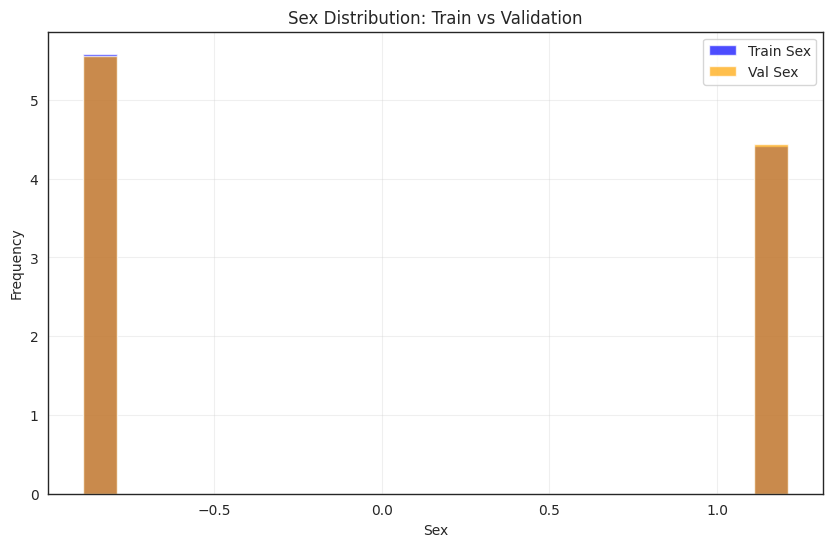

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate bin range to cover both datasets
min_sex = min(train_sex.min(), val_sex.min())
max_sex = max(train_sex.max(), val_sex.max())
bins = np.arange(min_sex, max_sex + 0.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(train_sex.flatten(), bins=bins, alpha=0.7, label='Train Sex', color='blue', density=True)
plt.hist(val_sex.flatten(), bins=bins, alpha=0.7, label='Val Sex', color='orange', density=True)
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.title('Sex Distribution: Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

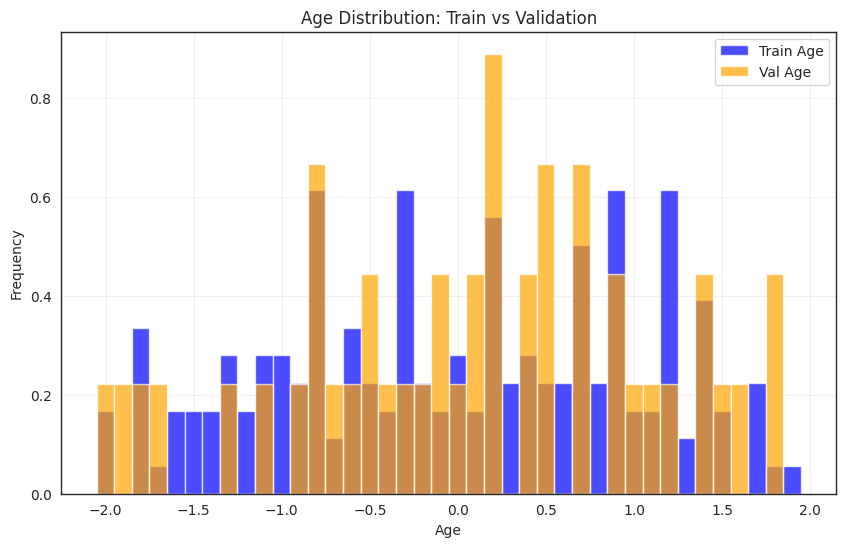

In [36]:
# Calculate bin range to cover both datasets
min_age = min(train_age.min(), val_age.min())
max_age = max(train_age.max(), val_age.max())
bins = np.arange(min_age, max_age + 0.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(train_age.flatten(), bins=bins, alpha=0.7, label='Train Age', color='blue', density=True)
plt.hist(val_age.flatten(), bins=bins, alpha=0.7, label='Val Age', color='orange', density=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution: Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

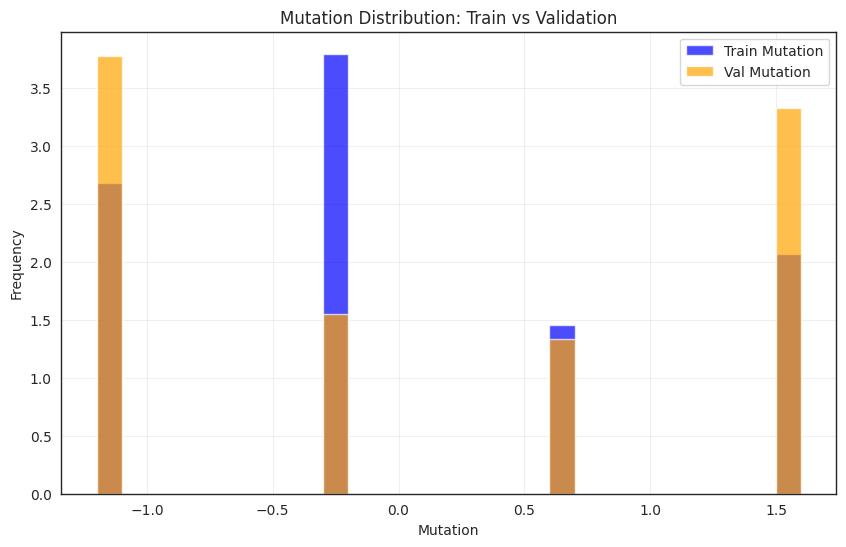

In [37]:
# Calculate bin range to cover both datasets
min_mutation = min(train_mutation.min(), val_mutation.min())
max_mutation = max(train_mutation.max(), val_mutation.max())
bins = np.arange(min_mutation, max_mutation + 0.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(train_mutation.flatten(), bins=bins, alpha=0.7, label='Train Mutation', color='blue', density=True)
plt.hist(val_mutation.flatten(), bins=bins, alpha=0.7, label='Val Mutation', color='orange', density=True)
plt.xlabel('Mutation')
plt.ylabel('Frequency')
plt.title('Mutation Distribution: Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
run_lasso_folds(num_folds=5, expand_features=True)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_n

{np.float64(0.0001): [0.733335499608077,
  1.1078785909760072,
  1.746015263673172,
  0.5711348155178838,
  0.5517629494400959],
 np.float64(0.00013257113655901095): [0.7296098372296913,
  0.8716640645179942,
  1.7363335071444768,
  0.640507862255903,
  0.4909915214916394],
 np.float64(0.00017575106248547912): [0.6939976499976762,
  0.7758839634594251,
  1.6998477487870303,
  0.6794901207517058,
  0.4658066586835991],
 np.float64(0.00023299518105153718): [0.6410896734209071,
  0.7106191802596916,
  1.6940250932216327,
  0.6957101964710755,
  0.5328620864804858],
 np.float64(0.00030888435964774815): [0.6505950564236169,
  0.6695439703088423,
  1.7318498908721756,
  0.715174358444991,
  0.7120861325233018],
 np.float64(0.00040949150623804275): [0.6632332266968174,
  0.6938664080309449,
  1.7371175190897776,
  0.6269329952326799,
  0.8943187900944043],
 np.float64(0.0005428675439323859): [0.688220055565385,
  0.7885983807980496,
  1.679029396767244,
  0.5884989188993085,
  0.7879485597073

In [5]:
run_lasso_folds(num_folds=5, expand_features=False)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_n

{np.float64(0.0001): [0.7333354996080753,
  1.1078785909760052,
  1.7460152636731734,
  0.5711348155178824,
  0.5517629494400955],
 np.float64(0.00013257113655901095): [0.7296098372296909,
  0.871664064517991,
  1.7363335071444788,
  0.6405078622559021,
  0.4909915214916404],
 np.float64(0.00017575106248547912): [0.6939976499976765,
  0.7758839634594246,
  1.6998477487870298,
  0.6794901207517057,
  0.4658066586835979],
 np.float64(0.00023299518105153718): [0.6410896734209071,
  0.710619180259692,
  1.6940250932216339,
  0.6957101964710743,
  0.5328620864804863],
 np.float64(0.00030888435964774815): [0.6505950564236177,
  0.6695439703088415,
  1.7318498908721738,
  0.7151743584449912,
  0.7120861325233018],
 np.float64(0.00040949150623804275): [0.6632332266968178,
  0.6938664080309445,
  1.7371175190897763,
  0.6269329952326793,
  0.8943187900944044],
 np.float64(0.0005428675439323859): [0.6882200555653846,
  0.788598380798049,
  1.6790293967672438,
  0.58849891889931,
  0.787948559707

In [5]:
run_lasso_folds(num_folds=5, expand_features=True)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_n

In [10]:
run_lasso_folds(num_folds=1, expand_features=True, k_fold=False)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_

{np.float64(0.0001): [0.46054439695937166],
 np.float64(0.00013257113655901095): [0.44442677999452734],
 np.float64(0.00017575106248547912): [0.4460385099631091],
 np.float64(0.00023299518105153718): [0.4724849128781766],
 np.float64(0.00030888435964774815): [0.4934201805030253],
 np.float64(0.00040949150623804275): [0.5085002877794874],
 np.float64(0.0005428675439323859): [0.5058349146746387],
 np.float64(0.0007196856730011522): [0.495849372248645],
 np.float64(0.0009540954763499944): [0.5036657305308045],
 np.float64(0.0012648552168552957): [0.5392229317698055],
 np.float64(0.0016768329368110084): [0.5655427633241406],
 np.float64(0.0022229964825261957): [0.577348640437889],
 np.float64(0.0029470517025518097): [0.5843245270654225],
 np.float64(0.003906939937054617): [0.5727218383255627],
 np.float64(0.005179474679231213): [0.5591397917761373],
 np.float64(0.006866488450042998): [0.5466427037532464],
 np.float64(0.009102981779915217): [0.5198157454665475],
 np.float64(0.01206792640639

In [ ]:
During the k-fold -> 143 training samples, validating on 36 samples
Final evaluation -> 179 total training samples, testing on 45
7258 proteins

SyntaxError: invalid syntax (3401389735.py, line 1)